# Tune LightGBM (14-Day) with Optuna
This notebook tunes LightGBM on the `lgbm_14` dataset using Optuna, then compares tuned vs untuned performance and visual diagnostics.

## 1) Imports and Paths
This cell imports all dependencies and defines data/report paths.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

try:
    import optuna
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])
    import optuna

RANDOM_SEED = 42
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed' / 'lgbm_14'
REPORTS_DIR = ROOT / 'artifacts' / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('REPORTS_DIR:', REPORTS_DIR)

DATA_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\lgbm_14
REPORTS_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Load Train/Val/Test
This cell loads the 14-day splits and confirms row/column/null counts.

In [2]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df = pd.read_csv(DATA_DIR / 'val.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

for d in [train_df, val_df, test_df]:
    d['date'] = pd.to_datetime(d['date'], errors='coerce')

summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'cols': train_df.shape[1], 'null_cells': int(train_df.isna().sum().sum())},
    {'split': 'val', 'rows': len(val_df), 'cols': val_df.shape[1], 'null_cells': int(val_df.isna().sum().sum())},
    {'split': 'test', 'rows': len(test_df), 'cols': test_df.shape[1], 'null_cells': int(test_df.isna().sum().sum())},
])
summary

,split,rows,cols,null_cells
0,train,67539,37,0
1,val,14370,37,0
2,test,15807,37,0


## 3) Define Target and Features
This cell sets the target and prepares feature matrices with robust numeric/categorical detection.

In [3]:
target_col = 'aggregated_sales_14'
feature_cols = [c for c in train_df.columns if c != target_col]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

categorical_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(X_train[c])]
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train[c])]

print('Target:', target_col)
print('Feature count:', len(feature_cols))
print('Numeric:', len(numeric_features), 'Categorical:', len(categorical_features))
print('Categorical features:', categorical_features)

Target: aggregated_sales_14
Feature count: 36
Numeric: 34 Categorical: 2
Categorical features: ['item_id', 'date']


## 4) Helpers and Baseline Model
This cell defines metrics, a pipeline builder, then trains an untuned LightGBM baseline.

In [4]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))

def compute_metrics(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'SMAPE': float(smape(y_true, y_pred)),
        'BIAS': float(np.mean(np.asarray(y_pred) - np.asarray(y_true))),
    }

def make_lgbm_pipeline(model_kwargs):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features),
        ]
    )

    model = LGBMRegressor(random_state=RANDOM_SEED, **model_kwargs)
    return Pipeline(steps=[('prep', preprocessor), ('model', model)])

untuned_params = dict(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=20,
    feature_fraction=1.0,
    bagging_fraction=1.0,
)

untuned_lgbm = make_lgbm_pipeline(untuned_params)
untuned_lgbm.fit(X_train, y_train)

pred_untuned_val = untuned_lgbm.predict(X_val)
pred_untuned_test = untuned_lgbm.predict(X_test)

baseline_val = compute_metrics(y_val, pred_untuned_val)
baseline_test = compute_metrics(y_test, pred_untuned_test)

pd.DataFrame([
    {'split': 'val', 'model': 'UntunedLGBM_14d', **baseline_val},
    {'split': 'test', 'model': 'UntunedLGBM_14d', **baseline_test},
])

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", l

[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0, subsample=1.0 will be ignored. Current value: bagging_fraction=1.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6214
[LightGBM] [Info] Number of data points in the train set: 67539, number of used features: 1517
[LightGBM] [Info] Start training from score 28.552969
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=1.0,

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,split,model,MAE,RMSE,SMAPE,BIAS
0,val,UntunedLGBM_14d,1.173756,2.789685,39.495864,-0.063104
1,test,UntunedLGBM_14d,1.238116,2.471524,28.902979,0.047674


## 5) Optuna Objective (with Stability Penalty)
This cell defines the Optuna objective using your exact parameter ranges and adds a penalty to reduce overfitting/instability.

In [5]:
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
    }

    model = make_lgbm_pipeline(params)
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)

    smape_train = smape(y_train, pred_train)
    smape_val = smape(y_val, pred_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
    bias_val = np.mean(pred_val - y_val)

    # Penalize instability and overfitting while still optimizing validation SMAPE.
    overfit_gap = abs(smape_val - smape_train)
    objective_value = smape_val + 0.40 * overfit_gap + 0.15 * abs(bias_val) + 0.05 * rmse_val
    return float(objective_value)

## 6) Run Optuna Search
This cell runs Bayesian optimization and shows the best objective value and best parameters.

In [6]:
N_TRIALS = 60
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print('Best objective:', study.best_value)
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

[I 2026-04-13 14:29:03,838] A new study created in memory with name: no-name-41f56d2e-2203-4665-a099-4ff630b5c782


[LightGBM] [Warning] feature_fraction is set=0.5780093202212182, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5780093202212182
[LightGBM] [Warning] bagging_fraction is set=0.5779972601681014, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5779972601681014
[LightGBM] [Warning] feature_fraction is set=0.5780093202212182, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5780093202212182
[LightGBM] [Warning] bagging_fraction is set=0.5779972601681014, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5779972601681014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005409 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3340
[LightGBM] [Info] Number of data points in the train set: 67539, number of used features: 80
[LightGBM] [Info] Start training from score 28.552969


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.5780093202212182, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5780093202212182
[LightGBM] [Warning] bagging_fraction is set=0.5779972601681014, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5779972601681014


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-04-13 14:29:07,658] Trial 0 finished with value: 41.40094284006653 and parameters: {'num_leaves': 69, 'learning_rate': 0.09556428757689246, 'n_estimators': 759, 'min_child_samples': 64, 'feature_fraction': 0.5780093202212182, 'bagging_fraction': 0.5779972601681014}. Best is trial 0 with value: 41.40094284006653.


...

[LightGBM] [Warning] feature_fraction is set=0.9103330800549784, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9103330800549784
[LightGBM] [Warning] bagging_fraction is set=0.6027896436766393, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6027896436766393
[LightGBM] [Warning] feature_fraction is set=0.8860507187856592, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8860507187856592
[LightGBM] [Warning] bagging_fraction is set=0.7695541757043467, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7695541757043467
[LightGBM] [Warning] feature_fraction is set=0.8860507187856592, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8860507187856592
[LightGBM] [Warning] bagging_fraction is set=0.7695541757043467, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7695541757043467
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016140 se

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8860507187856592, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8860507187856592
[LightGBM] [Warning] bagging_fraction is set=0.7695541757043467, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7695541757043467


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-04-13 14:34:25,051] Trial 59 finished with value: 41.04597583957448 and parameters: {'num_leaves': 62, 'learning_rate': 0.07734836283823585, 'n_estimators': 464, 'min_child_samples': 25, 'feature_fraction': 0.8860507187856592, 'bagging_fraction': 0.7695541757043467}. Best is trial 14 with value: 40.96225364208094.


[LightGBM] [Warning] feature_fraction is set=0.8860507187856592, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8860507187856592
[LightGBM] [Warning] bagging_fraction is set=0.7695541757043467, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7695541757043467
Best objective: 40.96225364208094
Best params:
  num_leaves: 54
  learning_rate: 0.06315341191679866
  n_estimators: 469
  min_child_samples: 41
  feature_fraction: 0.90176005200193
  bagging_fraction: 0.9959437324252536


## 7) Train Tuned Model and Compare vs Untuned
This cell trains the tuned model and compares tuned vs untuned metrics on validation and test, including val-test gaps.

In [7]:
best_params = study.best_params.copy()
tuned_lgbm = make_lgbm_pipeline(best_params)
tuned_lgbm.fit(X_train, y_train)

pred_tuned_val = tuned_lgbm.predict(X_val)
pred_tuned_test = tuned_lgbm.predict(X_test)

tuned_val = compute_metrics(y_val, pred_tuned_val)
tuned_test = compute_metrics(y_test, pred_tuned_test)

metrics_rows = [
    {'split': 'val', 'model': 'UntunedLGBM_14d', **baseline_val},
    {'split': 'test', 'model': 'UntunedLGBM_14d', **baseline_test},
    {'split': 'val', 'model': 'TunedLGBM_14d', **tuned_val},
    {'split': 'test', 'model': 'TunedLGBM_14d', **tuned_test},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_df['BIAS_abs'] = metrics_df['BIAS'].abs()
metrics_df = metrics_df[['split', 'model', 'MAE', 'RMSE', 'SMAPE', 'BIAS', 'BIAS_abs']]

gap_rows = []
for model_name in metrics_df['model'].unique():
    tmp = metrics_df[metrics_df['model'] == model_name].set_index('split')
    gap_rows.append({
        'model': model_name,
        'MAE_gap_abs': abs(tmp.loc['test', 'MAE'] - tmp.loc['val', 'MAE']),
        'RMSE_gap_abs': abs(tmp.loc['test', 'RMSE'] - tmp.loc['val', 'RMSE']),
        'SMAPE_gap_abs': abs(tmp.loc['test', 'SMAPE'] - tmp.loc['val', 'SMAPE']),
        'BIAS_gap_abs': abs(tmp.loc['test', 'BIAS'] - tmp.loc['val', 'BIAS']),
    })
gap_df = pd.DataFrame(gap_rows)

display(metrics_df.sort_values(['split', 'SMAPE']))
display(gap_df.sort_values('SMAPE_gap_abs'))

[LightGBM] [Warning] feature_fraction is set=0.90176005200193, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.90176005200193
[LightGBM] [Warning] bagging_fraction is set=0.9959437324252536, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9959437324252536
[LightGBM] [Warning] feature_fraction is set=0.90176005200193, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.90176005200193
[LightGBM] [Warning] bagging_fraction is set=0.9959437324252536, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9959437324252536
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009472 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6214
[LightGBM] [Info] Number of data points in the train set: 67539, number of used features: 1517
[LightGBM] [Info] Start training from score 28.552969


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.90176005200193, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.90176005200193
[LightGBM] [Warning] bagging_fraction is set=0.9959437324252536, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9959437324252536
[LightGBM] [Warning] feature_fraction is set=0.90176005200193, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.90176005200193
[LightGBM] [Warning] bagging_fraction is set=0.9959437324252536, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9959437324252536


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,split,model,MAE,RMSE,SMAPE,BIAS,BIAS_abs
3,test,TunedLGBM_14d,1.263410,3.291163,28.875111,0.061362,0.061362
1,test,UntunedLGBM_14d,1.238116,2.471524,28.902979,0.047674,0.047674
2,val,TunedLGBM_14d,1.185008,2.774164,39.459171,-0.073250,0.073250
0,val,UntunedLGBM_14d,1.173756,2.789685,39.495864,-0.063104,0.063104


,model,MAE_gap_abs,RMSE_gap_abs,SMAPE_gap_abs,BIAS_gap_abs
1,TunedLGBM_14d,0.078401,0.516999,10.584060,0.134611
0,UntunedLGBM_14d,0.064360,0.318161,10.592885,0.110778


## 8) Actual vs Predicted (Test)
This cell plots daily-average actual values and predictions for untuned vs tuned LightGBM.

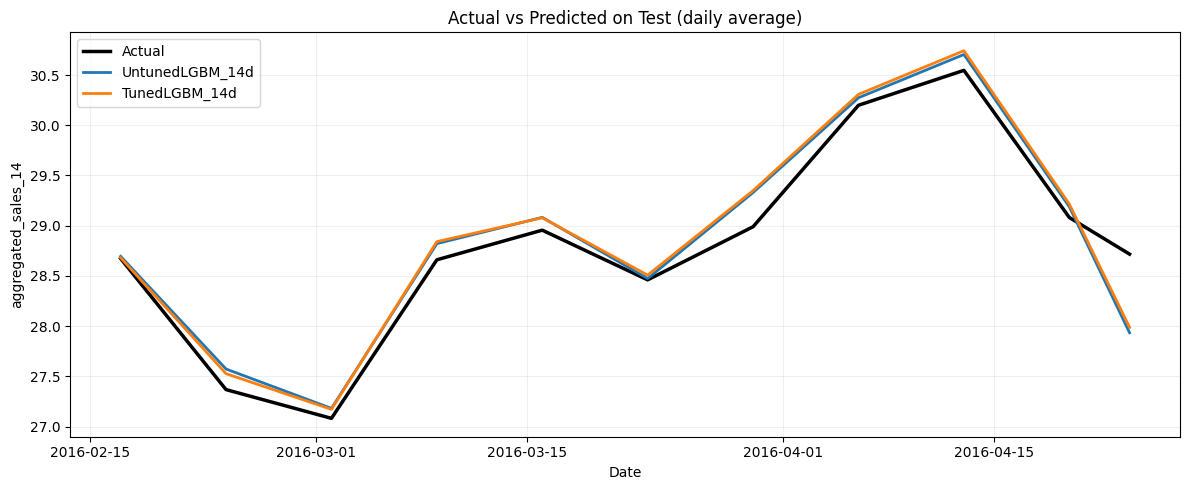

In [8]:
curve_df = X_test[['date']].copy()
curve_df['actual'] = y_test.values
curve_df['untuned'] = pred_untuned_test
curve_df['tuned'] = pred_tuned_test
curve_df = curve_df.groupby('date', as_index=False).mean(numeric_only=True).sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(curve_df['date'], curve_df['actual'], label='Actual', color='black', linewidth=2.5)
plt.plot(curve_df['date'], curve_df['untuned'], label='UntunedLGBM_14d', linewidth=2)
plt.plot(curve_df['date'], curve_df['tuned'], label='TunedLGBM_14d', linewidth=2)
plt.title('Actual vs Predicted on Test (daily average)')
plt.xlabel('Date')
plt.ylabel('aggregated_sales_14')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 9) Residual Distribution (Test)
This cell compares residual distributions of untuned vs tuned LightGBM on the test split.

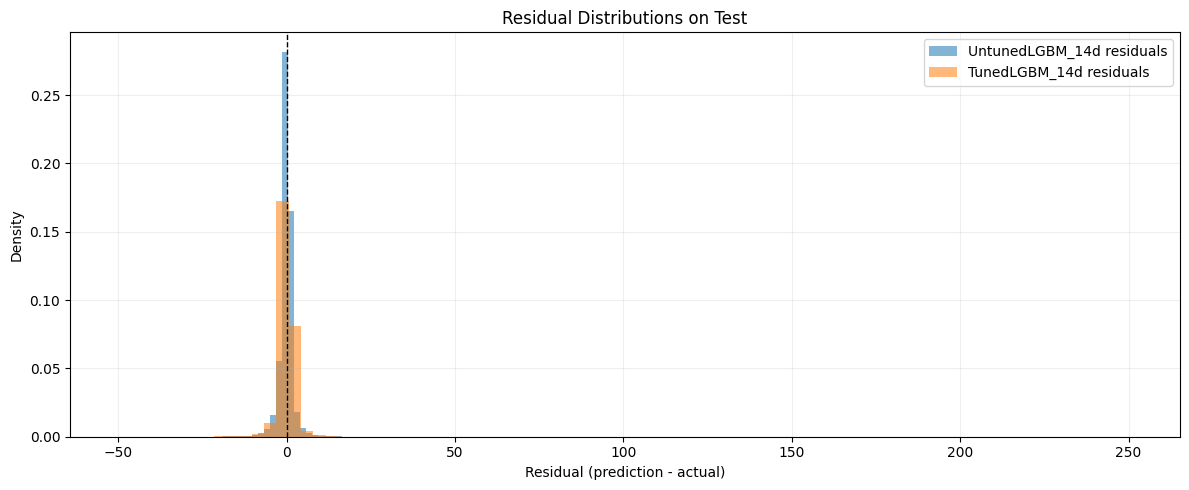

In [9]:
res_untuned = pred_untuned_test - y_test.values
res_tuned = pred_tuned_test - y_test.values

plt.figure(figsize=(12, 5))
plt.hist(res_untuned, bins=80, alpha=0.55, density=True, label='UntunedLGBM_14d residuals')
plt.hist(res_tuned, bins=80, alpha=0.55, density=True, label='TunedLGBM_14d residuals')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Distributions on Test')
plt.xlabel('Residual (prediction - actual)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 10) Save Outputs
This cell saves metrics, val-test gap summary, prediction curves, and best parameters.

In [10]:
metrics_path = REPORTS_DIR / 'metrics_lgbm_14_tuned_vs_untuned.csv'
gap_path = REPORTS_DIR / 'metrics_lgbm_14_val_test_gap_tuned_vs_untuned.csv'
curve_path = REPORTS_DIR / 'predictions_curve_lgbm_14_tuned_vs_untuned.csv'
best_params_path = REPORTS_DIR / 'best_params_lgbm_14_optuna.json'

metrics_df.to_csv(metrics_path, index=False)
gap_df.to_csv(gap_path, index=False)
curve_df.to_csv(curve_path, index=False)

import json
with open(best_params_path, 'w', encoding='utf-8') as f:
    json.dump(best_params, f, indent=2)

print('Saved metrics:', metrics_path)
print('Saved val-test gap:', gap_path)
print('Saved curve:', curve_path)
print('Saved best params:', best_params_path)

Saved metrics: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\metrics_lgbm_14_tuned_vs_untuned.csv
Saved val-test gap: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\metrics_lgbm_14_val_test_gap_tuned_vs_untuned.csv
Saved curve: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\predictions_curve_lgbm_14_tuned_vs_untuned.csv
Saved best params: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\best_params_lgbm_14_optuna.json


In [11]:
import json
import joblib

MODELS_DIR = ROOT / 'artifacts' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

untuned_model_path = MODELS_DIR / 'untuned_lgbm_14.joblib'
untuned_params_path = MODELS_DIR / 'untuned_lgbm_14_params.json'

joblib.dump(untuned_lgbm, untuned_model_path)

with open(untuned_params_path, 'w', encoding='utf-8') as f:
    json.dump(untuned_params, f, indent=2)

print(f'Saved untuned model: {untuned_model_path}')
print(f'Saved untuned params: {untuned_params_path}')

Saved untuned model: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\untuned_lgbm_14.joblib
Saved untuned params: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\untuned_lgbm_14_params.json
